1. Overall survival rate:
38.38383838383838

2. Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

3. Survival rate by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

4. Average age survivors vs non survivors:
Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

5. Average fare by class:
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
Pclass  Sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: Survived, dtype: float64


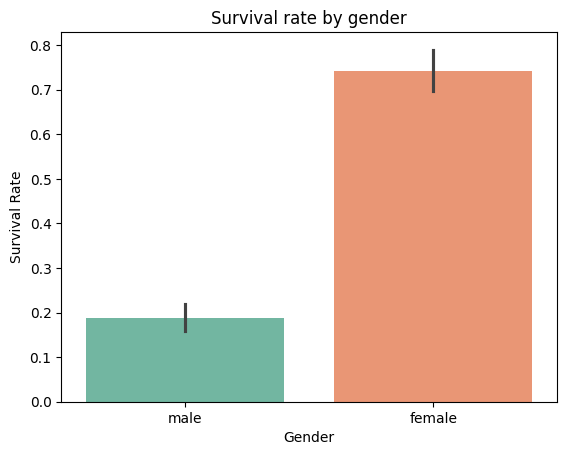

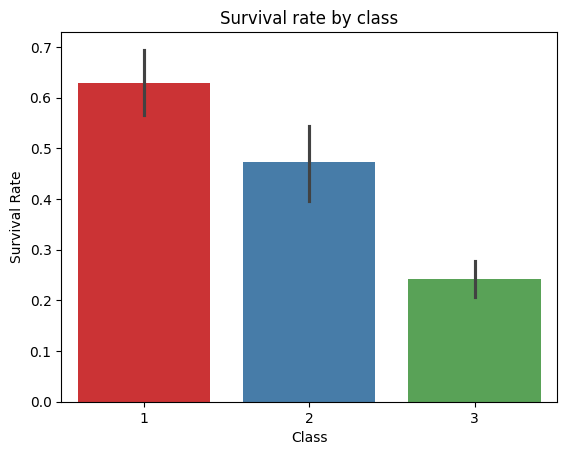

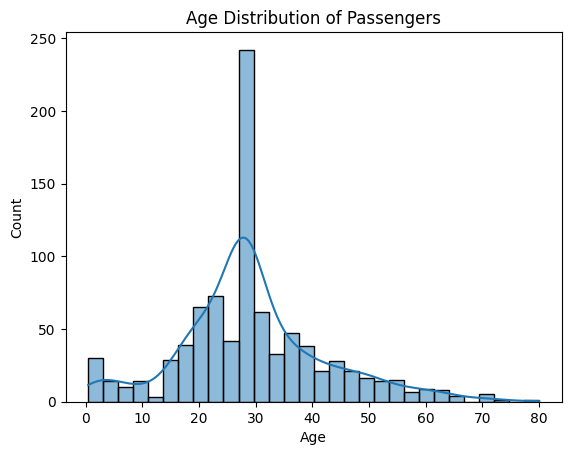

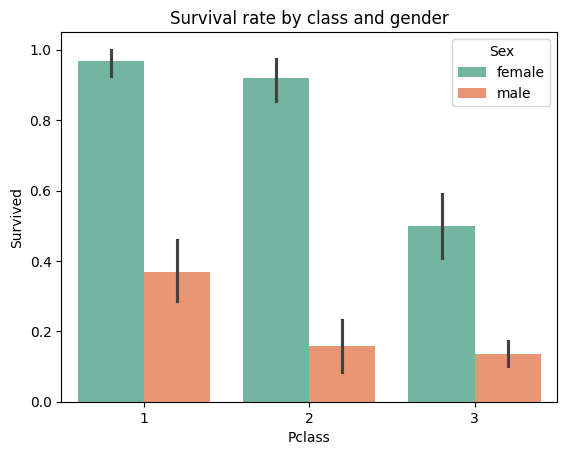

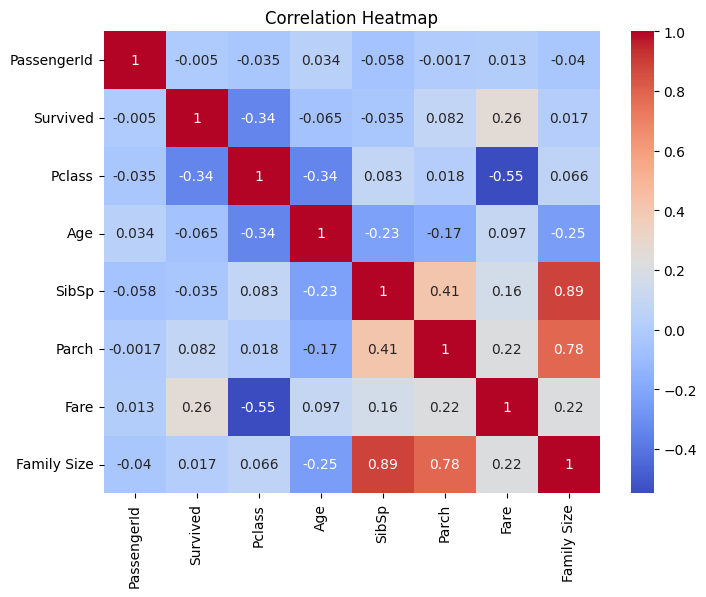

/tmp/ipykernel_382/2701321054.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='Pclass',y='Fare',palette='Set2')


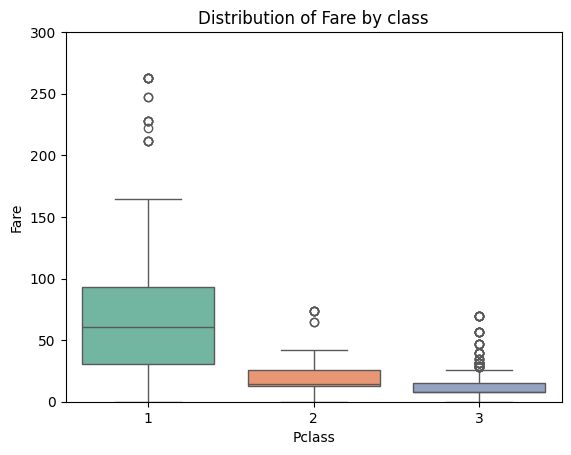

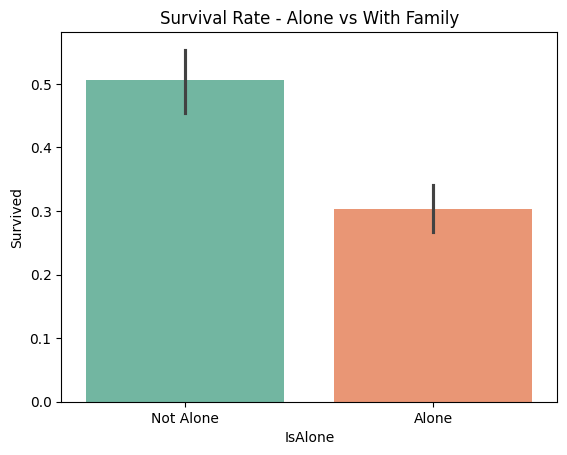

/tmp/ipykernel_382/2701321054.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='AgeGroup', y='Survived', palette='Set2')


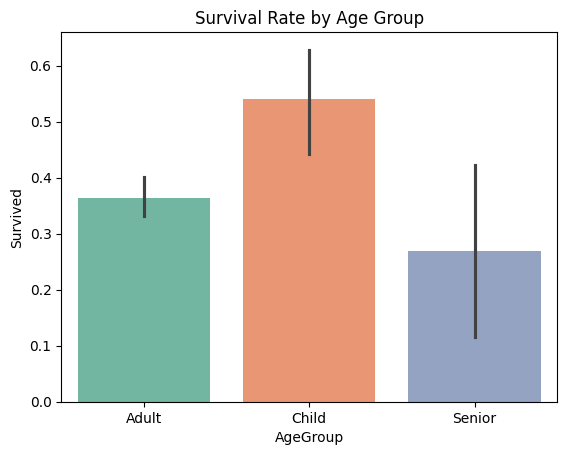

/tmp/ipykernel_382/2701321054.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FareCategory', y='Survived',


AgeGroup
Adult     36.436170
Child     53.982301
Senior    26.923077
Name: Survived, dtype: float64


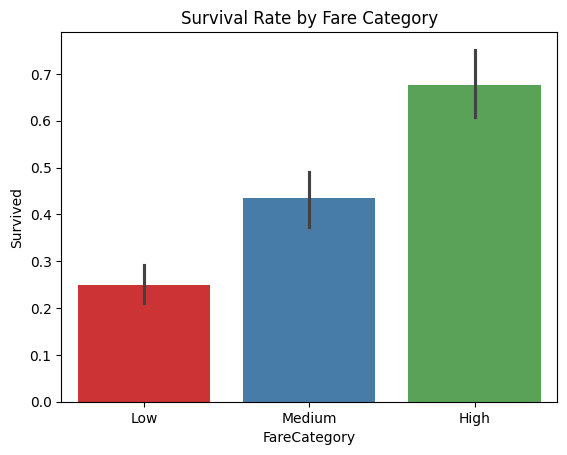

FareCategory
High      67.701863
Low       24.945295
Medium    43.589744
Name: Survived, dtype: float64


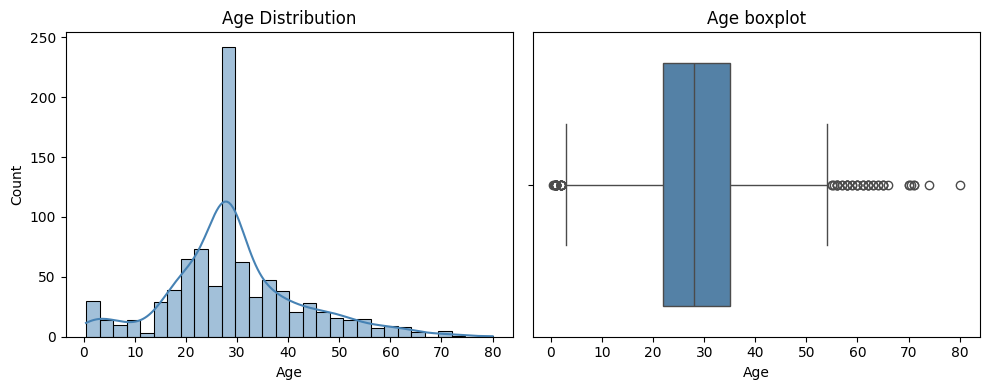

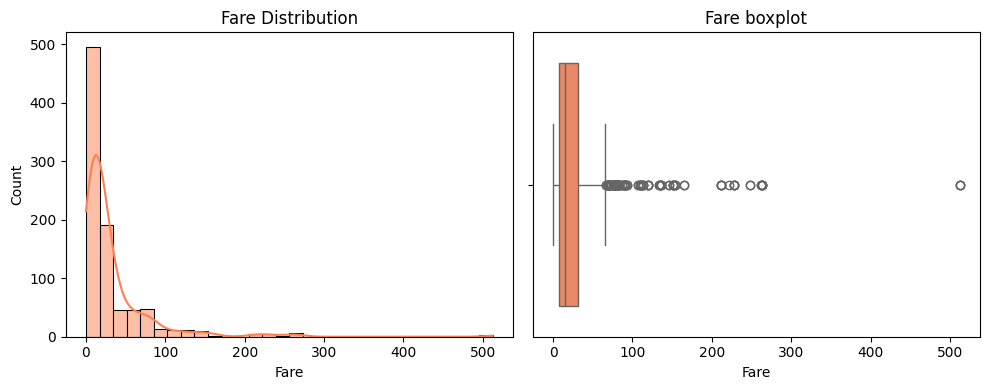

/tmp/ipykernel_382/2701321054.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Survived',palette='Set2',ax=axes[0])
/tmp/ipykernel_382/2701321054.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died','Survived'])
/tmp/ipykernel_382/2701321054.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='Sex',palette='Set1',ax=axes[1])
/tmp/ipykernel_382/2701321054.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

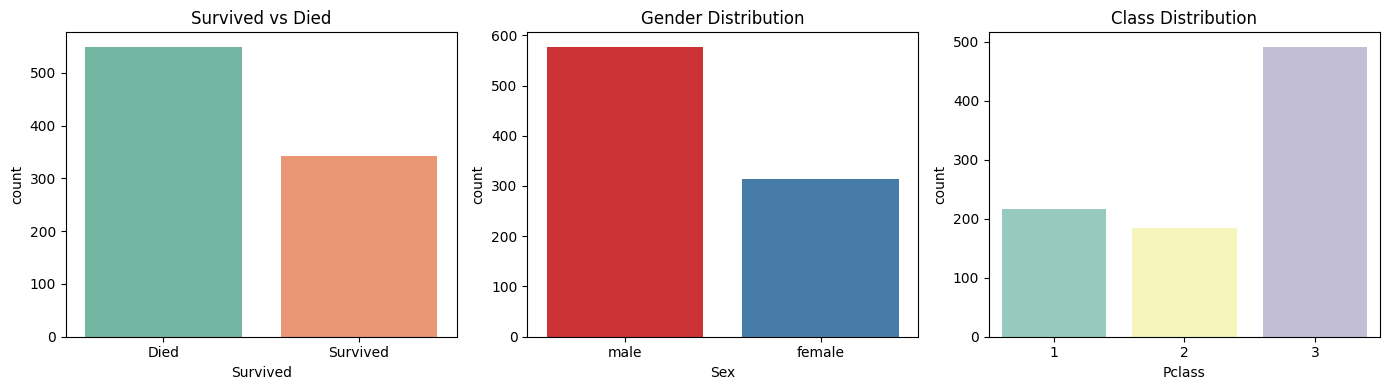

/tmp/ipykernel_382/2701321054.py:146: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Age',
/tmp/ipykernel_382/2701321054.py:149: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])
/tmp/ipykernel_382/2701321054.py:152: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare',
/tmp/ipykernel_382/2701321054.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Died', 'Survived'])
/tmp/ipykernel_382/2701321054.py:158:

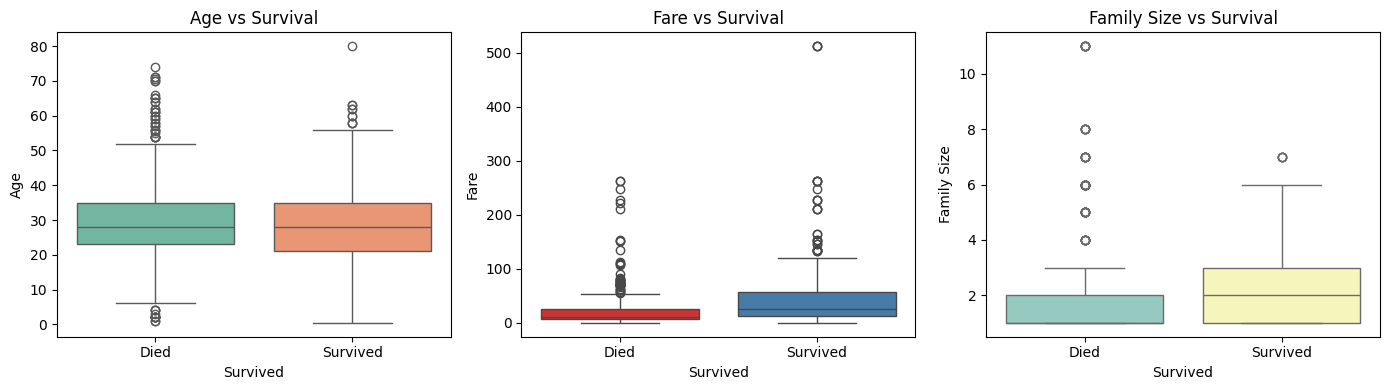

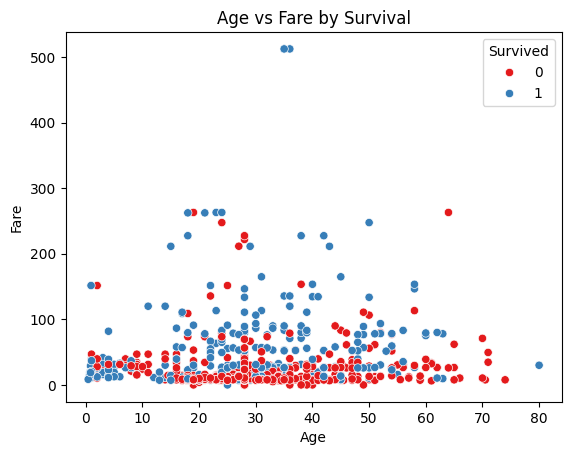

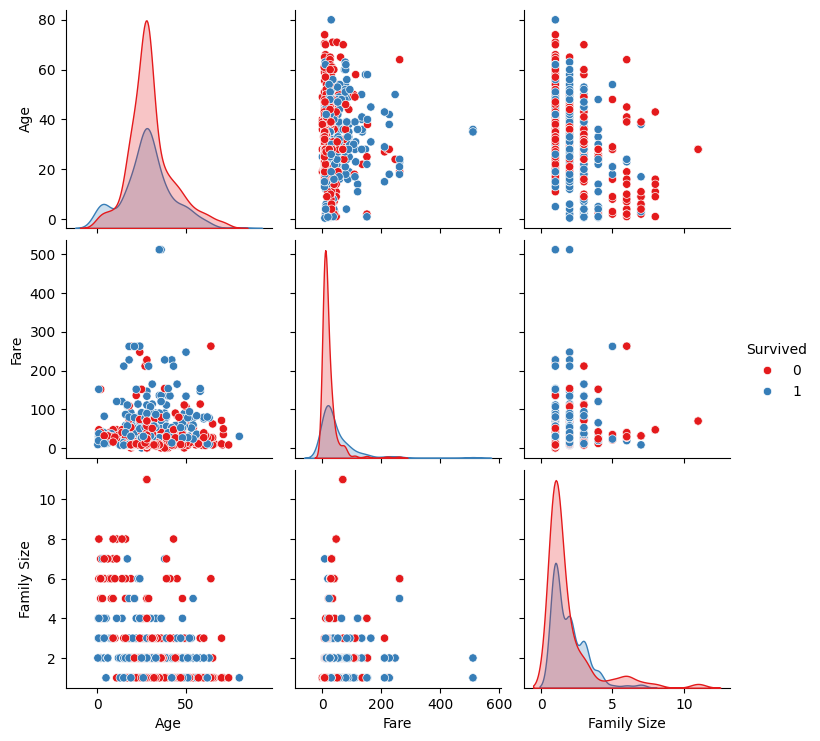

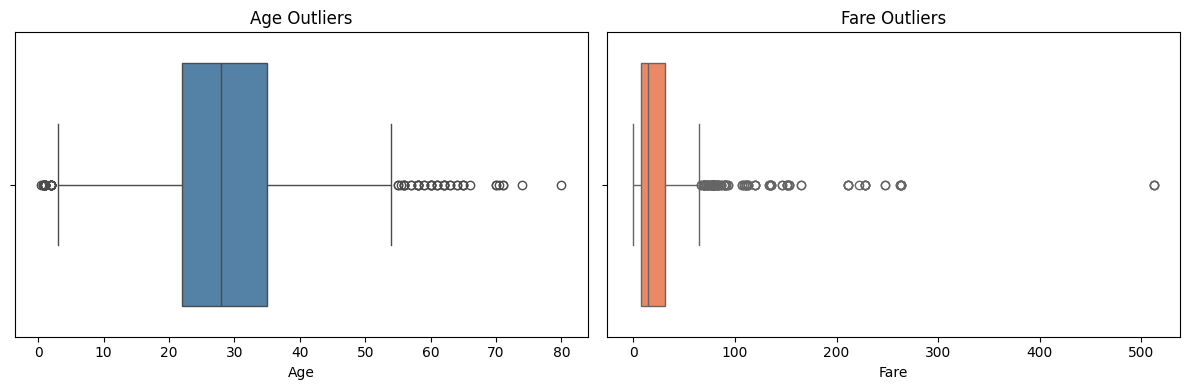

Number of outliers in Fare: 116
Lower bound: -26.724
Upper bound: 65.6344
Original Fare max: 512.3292
Capped Fare max: 65.6344
Number of outliers in Age: 66
Lower bound: 2.5
Upper bound: 54.5


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
#DATA CLEANING
df['Age'] = df['Age'].fillna(df['Age'].median())
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
#FEATURE ENGINEERING
df['Family Size']=df['SibSp']+df['Parch']+1
df['IsAlone'] = df['Family Size'].apply(
    lambda x: 'Alone' if x == 1 else 'Not Alone'
)

def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df['AgeGroup'] = df['Age'].apply(age_group)

def fare_category(fare):
    if fare < 15:
        return 'Low'
    elif fare < 50:
        return 'Medium'
    else:
        return 'High'

df['FareCategory'] = df['Fare'].apply(fare_category)
#TEXT EXTRACTED DATA
print("1. Overall survival rate:")
print(df['Survived'].mean() * 100)

print("\n2. Survival rate by gender:")
print(df.groupby('Sex')['Survived'].mean() * 100)

print("\n3. Survival rate by class:")
print(df.groupby('Pclass')['Survived'].mean() * 100)

print("\n4. Average age survivors vs non survivors:")
print(df.groupby('Survived')['Age'].mean())

print("\n5. Average fare by class:")
print(df.groupby('Pclass')['Fare'].mean())
print(df.groupby(['Pclass','Sex'])['Survived'].mean() * 100)

#VISUALLY EXTRACTED DATA
#SURVIVAL RATE BY GENDER
sns.barplot(data=df,x='Sex',y='Survived',hue='Sex',palette='Set2', legend=False)
plt.title('Survival rate by gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()
#SURVIVAL RATE BY CLASS
sns.barplot(data=df,x='Pclass',y='Survived',hue='Pclass',palette='Set1', legend=False)
plt.title('Survival rate by class')
plt.xlabel('Class')
plt.ylabel('Survival Rate')
plt.show()
#AGE DISTRIBUTION
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.show()
#SURVIVAL RATE BY CLASS AND GENDER
sns.barplot(data=df,x='Pclass',y='Survived',hue='Sex',palette='Set2')
plt.title('Survival rate by class and gender')
plt.show()
#CORRELATION HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
#FARE CLASS DISTRIBUTION
sns.boxplot(data=df,x='Pclass',y='Fare',palette='Set2')
plt.title('Distribution of Fare by class')
plt.ylim(0,300)
plt.show()
#SURVIVAL RATE ALONE/FAMILY
sns.barplot(data=df, x='IsAlone', y='Survived', hue='IsAlone', palette='Set2', legend=False)
plt.title('Survival Rate - Alone vs With Family')
plt.show()
#SURVIVAL RATE BY AGE GROUP
sns.barplot(data=df, x='AgeGroup', y='Survived', palette='Set2')
plt.title('Survival Rate by Age Group')
plt.show()

print(df.groupby('AgeGroup')['Survived'].mean() * 100)
#FARE CATEGORIES
sns.barplot(data=df, x='FareCategory', y='Survived',
            order=['Low','Medium','High'], palette='Set1')
plt.title('Survival Rate by Fare Category')
plt.show()

print(df.groupby('FareCategory')['Survived'].mean() * 100)
#UNIVARIATE
#AGE DISTRIBUTION
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data=df,x='Age',bins=30,kde=True,color='steelblue')
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='Age',color='steelblue')
plt.title('Age boxplot')
plt.tight_layout()
plt.show()

#FARE DISTRIBUTION
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(data=df,x='Fare',bins=30,kde=True,color='coral')
plt.title('Fare Distribution')

plt.subplot(1,2,2)
sns.boxplot(data=df,x='Fare',color='coral')
plt.title('Fare boxplot')
plt.tight_layout()
plt.show()
#BIVARIATE
#SURVIVED VS DIED
fig, axes = plt.subplots(1, 3, figsize=(14,4))

sns.countplot(data=df,x='Survived',palette='Set2',ax=axes[0])
axes[0].set_title('Survived vs Died')
axes[0].set_xticklabels(['Died','Survived'])
#GENDER COUNT
sns.countplot(data=df,x='Sex',palette='Set1',ax=axes[1])
axes[1].set_title('Gender Distribution')
#CLASS COUNT
sns.countplot(data=df,x='Pclass',palette='Set3',ax=axes[2])
axes[2].set_title('Class Distribution')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14,4))

# Age vs Survived
sns.boxplot(data=df, x='Survived', y='Age',
            palette='Set2', ax=axes[0])
axes[0].set_title('Age vs Survival')
axes[0].set_xticklabels(['Died', 'Survived'])

# Fare vs Survived
sns.boxplot(data=df, x='Survived', y='Fare',
            palette='Set1', ax=axes[1])
axes[1].set_title('Fare vs Survival')
axes[1].set_xticklabels(['Died', 'Survived'])

# FamilySize vs Survived
sns.boxplot(data=df, x='Survived', y='Family Size',
            palette='Set3', ax=axes[2])
axes[2].set_title('Family Size vs Survival')
axes[2].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.show()

#MULTIVARIATE
#AGE VS FARE VS SURVIVED
sns.scatterplot(data=df, x='Age', y='Fare',
                hue='Survived', palette='Set1')
plt.title('Age vs Fare by Survival')
plt.show()
#PAIRPLOTS
sns.pairplot(df[['Age', 'Fare', 'Family Size', 'Survived']],
             hue='Survived',
             palette='Set1',
             diag_kind='kde')
plt.show()

#OUTLIER DETECTION
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(data=df, x='Age', color='steelblue', ax=axes[0])
axes[0].set_title('Age Outliers')

sns.boxplot(data=df, x='Fare', color='coral', ax=axes[1])
axes[1].set_title('Fare Outliers')

plt.tight_layout()
plt.show()

#FARE OUTLIERS
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(f"Number of outliers in Fare: {len(outliers)}")
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")

df['Fare_capped'] = df['Fare'].clip(upper=upper)

print("Original Fare max:", df['Fare'].max())
print("Capped Fare max:", df['Fare_capped'].max())
#AGE OUTLIERS
Q1=df['Age'].quantile(0.25)
Q3=df['Age'].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df['Age']<lower)|(df['Age']>upper)]
print(f"Number of outliers in Age: {len(outliers)}")
print(f"Lower bound: {lower}")
print(f"Upper bound: {upper}")

